In [1]:
library(data.table)
# library(eulerr)
library(Chicdiff)
library(ggplot2)
# library(EnhancedVolcano)
library(ggrepel)
library(RColorBrewer)
# library(topGO)
library(dplyr)

# library(clusterProfiler)
# library(org.Hs.eg.db)




Welcome to Chicdiff - version 0.6

If you are new to Chicdiff, please consider reading the vignette through the command: vignette("Chicdiff").


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# loading chicdiff results for ILC for each resolution
diffs_fres <- readRDS("~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_fragres/ILC_CD4_fragres_results.Rds")
diffs_5kb <- readRDS("~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_DII_5kb/ILC_CD4_DII_5kb_results.Rds")
# diffs_20kb <- readRDS("~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_DII_20kb/ILC_CD4_DII_20kb_results.Rds")


In [3]:
# loading baitmaps for each resolution
bmap_fres <- "~/spivakov_analysis_live/Design/Human_DpnII_binsize1500_maxL75K/hg38_dpnII.baitmap"
bmap_5kb <- "~/spivakov_analysis_live/Design/Human_hg38_bin5K_sol_baits/human_DpnII_5K_sol_baits.baitmap"
# bmap_20kb <- fread("~/spivakov_analysis_live/Design/Human_hg38_bin20K_sol_baits/hg38_dpnII_20kb_sol_baits.baitmap")

In [4]:
# checking the number of significant interactions at each resolution

nrow(diffs_fres[weighted_padj < 0.05])
nrow(diffs_5kb[weighted_padj < 0.05])
# nrow(diffs_20kb[weighted_padj < 0.05])

[1] 1818

[1] 17220

In [17]:
# sum to the total number of interactions

nrow(diffs_fres[weighted_padj < 0.05])+
nrow(diffs_5kb[weighted_padj < 0.05]) 
# nrow(diffs_20kb[weighted_padj < 0.05])

[1] 19038

In [4]:
# merge chicdiff results with baitmaps to get the bait-gene annotation

diffs_fres_bmap <- merge(diffs_fres, bmap_fres, by.x = "baitID", by.y = "V4", all.x = TRUE)
diffs_5kb_bmap <- merge(diffs_5kb, bmap_5kb, by.x = "baitID", by.y = "V4", all.x = TRUE)
# diffs_20kb_bmap <- merge(diffs_20kb, bmap_20kb, by.x = "baitID", by.y = "V4", all.x = TRUE)

In [14]:
# checking the number of unique genes at each resolution

length(unique(diffs_fres_bmap[weighted_padj < 0.05]$V5))
length(unique(diffs_5kb_bmap[weighted_padj < 0.05]$V5))
# length(unique(diffs_20kb_bmap[weighted_padj < 0.05]$V5))

[1] 859

[1] 3140

In [15]:
# total number of unique genes differentially wired:
length(unique(c(unlist(strsplit(diffs_fres_bmap[weighted_padj < 0.05]$V5, ",")),unlist(strsplit(diffs_5kb_bmap[weighted_padj < 0.05]$V5, ",")))))


[1] 3664

In [5]:
# overlap between ILC3 and CD4+ T cell chicdiff genes

ilc3_diff_genes <- unique(c(unlist(strsplit(diffs_fres_bmap[log2FoldChange > 0 ][weighted_padj < 0.05]$V5, ",")),
                                 unlist(strsplit(diffs_5kb_bmap[log2FoldChange > 0 ][weighted_padj < 0.05]$V5, ","))))

cd4_diff_genes <- unique(c(unlist(strsplit(diffs_fres_bmap[log2FoldChange < 0 ][weighted_padj < 0.05]$V5, ",")),
                                 unlist(strsplit(diffs_5kb_bmap[log2FoldChange < 0 ][weighted_padj < 0.05]$V5, ","))))

In [21]:
ilc3_cd4_shared_chicdiff <- intersect(ilc3_diff_genes, cd4_diff_genes)
ilc3_only_chicdiff <- setdiff(ilc3_diff_genes, ilc3_cd4_shared_chicdiff)
cd4_only_chicdiff <- setdiff(cd4_diff_genes, ilc3_cd4_shared_chicdiff)

sapply(list(ilc3_only_chicdiff, ilc3_cd4_shared_chicdiff, cd4_only_chicdiff), length)

[1] 2105  194 1365

In [26]:
chicdiff_genes <- data.table(
  gene = union(ilc3_diff_genes, cd4_diff_genes),
  type = ifelse(union(ilc3_diff_genes, cd4_diff_genes) %in% ilc3_cd4_shared_chicdiff, "shared",
         ifelse(union(ilc3_diff_genes, cd4_diff_genes) %in% ilc3_only_chicdiff, "ilc3-specific", "cd4-specific"))
)

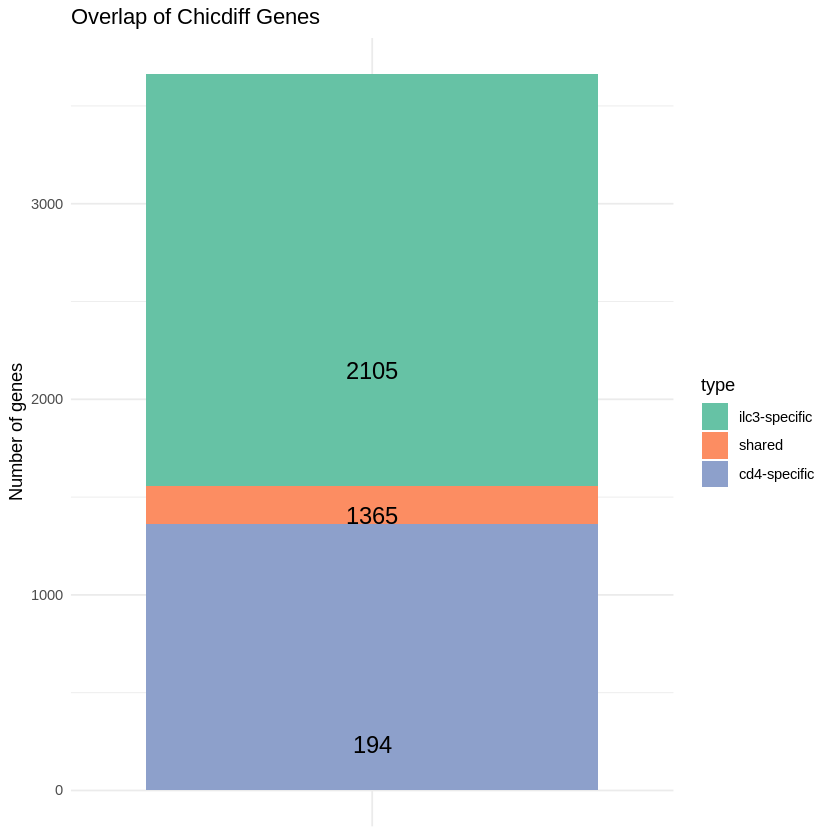

In [119]:
# Stacked barplot: one bar total, filled by type
library(RColorBrewer)
pal <- brewer.pal(3, "Set2")

counts <- chicdiff_genes[, .N, by = type]
counts[, type := factor(type, levels = c("ilc3-specific", "shared", "cd4-specific"))]



# Horizontal stacked bar plot with labels above each section
p <- ggplot(counts, aes(x = "Genes", y = N, fill = type)) +
  geom_bar(stat = "identity") +
  labs(title = "Overlap of Chicdiff Genes",
       x = NULL, y = "Number of genes") +
  scale_fill_manual(values = pal) +
  theme_minimal() +
  theme(axis.text.x = element_blank(),
        axis.ticks.x = element_blank())

# Show plot
p

# Save to file
ggsave("~/miniPCHiC/hILCs/Chicdiff/chicdiff_genes_horizontal_bar_labels.pdf", p, width = 3, height = 8, dpi = 300, useDingbats = FALSE)


In [20]:
# checking the total number of unique genes at all resolutions

# all_diffs <- rbind(diffs_fres_bmap[weighted_padj < 0.05],
#               diffs_5kb_bmap[weighted_padj < 0.05],
#               diffs_20kb_bmap[weighted_padj < 0.05])
# length(unique(all_diffs$V5))

all_diffs <- rbind(diffs_fres_bmap[weighted_padj < 0.05],
              diffs_5kb_bmap[weighted_padj < 0.05])
length(unique(all_diffs$V5))

[1] 3664

In [9]:
head(all_diffs[V5 == "CLN3"])
fwrite(all_diffs, "chicdiff_differentially_wired_genes_5kb_fres_merged.txt")

baitID,group,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maxOE,minOE,⋯,shuff,avgLogDist,avWeights,weight,weighted_pvalue,weighted_padj,V1,V2,V3,V5
<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<chr>
2314201,1,104.87525,1.022694,0.2516982,4.063176,4.840947e-05,2.488651e-03,2314199,2314191,⋯,0.02462957,7.293169,22.925060,3.787495,1.278139e-05,2.240669e-03,16,28492255,28492527,CLN3
186288,2,24.21910,1.670016,0.4703494,3.550587,3.843728e-04,4.759358e-03,186310,186300,⋯,0.86381988,10.908347,8.589892,2.548687,1.508121e-04,2.487625e-03,16,28492067,28492254,CLN3
186288,2,21.89207,1.687838,0.4859764,3.473086,5.145099e-04,6.001708e-03,186311,186301,⋯,0.35025079,10.984524,8.589892,2.548687,2.018725e-04,3.147055e-03,16,28492067,28492254,CLN3
186289,1,194.26075,1.260623,0.1950611,6.462707,1.028466e-10,1.389386e-08,186302,186292,⋯,0.42618095,9.922430,21.725504,6.446124,1.595480e-11,2.855751e-09,16,28492255,28492527,CLN3
186289,1,183.90848,1.241186,0.2001330,6.201805,5.581907e-10,6.094879e-08,186303,186293,⋯,0.06689398,10.101679,21.725504,6.446124,8.659323e-11,1.237842e-08,16,28492255,28492527,CLN3
186289,2,173.20762,1.520158,0.2199544,6.911241,4.804325e-12,9.791033e-10,186306,186296,⋯,0.57561439,10.524335,8.589892,2.548687,1.885020e-12,4.545883e-10,16,28492255,28492527,CLN3


In [6]:
## factoring ILC3 genes for plotting
# GADD45A / CXCR5

diffs_5kb_bmap[,colour:= ifelse(V5 == "CLN3", "CLN3", 
                                ifelse(V5 == "IL1R1", "IL1R1", 
                                       ifelse(V5 == "GADD45A", "GADD45A",
                                            ifelse(V5 == "NFRKB", "NFRKB",  
                                                ifelse(V5 == "PLCL1", "PLCL1",
                                                    ifelse(V5 == "IL23R", "IL23R", 
                                                        ifelse(V5 =="IKZF1", "IKZF1", "grey30")))))))]
diffs_5kb_bmap[,colour := factor(colour, levels = c("CLN3", "IL1R1", "GADD45A", "NFRKB", "IL23R", "PLCL1", "IKZF1", "grey30"))]

In [22]:
unique(diffs_5kb_bmap[weighted_padj < 0.0001 & log2FoldChange < -2]$V5)

[1] "SEP15/HS2ST1" "FAM46C"       "CD6"          "NFRKB"        "CDC16"       
 [6] "BCL11B"       "MT1G"         "ZBTB14"       "ATP13A1"      "PLCL1"       
[11] "ZBTB20"       "HIVEP1"

Warning message:
“Removed 2 rows containing missing values (geom_point).”


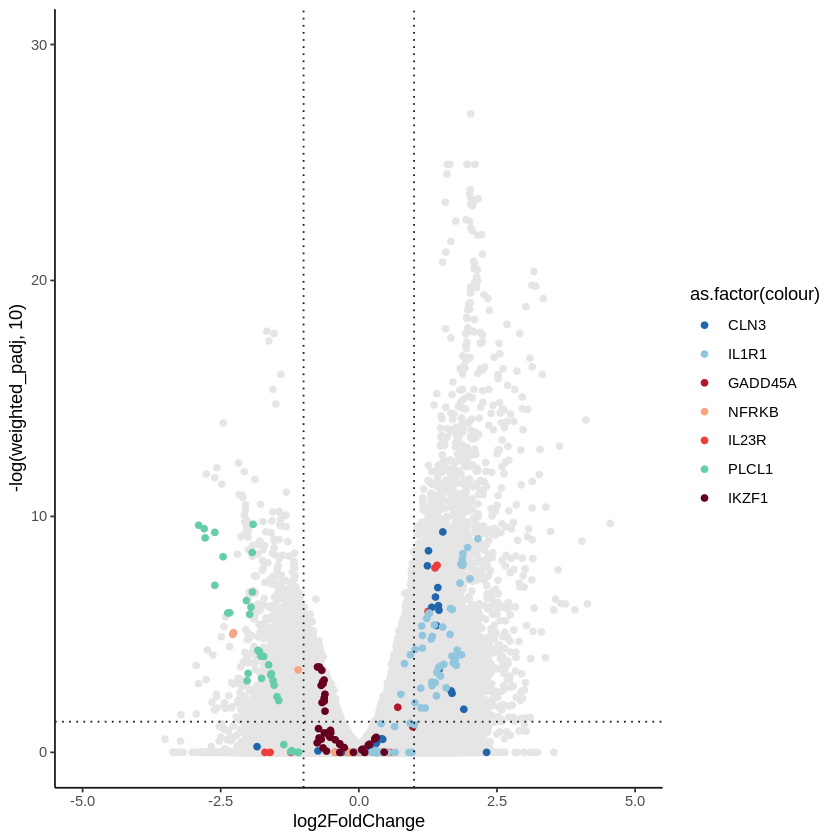

In [26]:
# plotting volcano plot chicdiff 5kb. Colouring ILC3 genes

ggplot(diffs_5kb_bmap[!(colour == "grey30")], aes(x=log2FoldChange, y=-log(weighted_padj, 10))) +
    geom_point(data = diffs_5kb_bmap[(colour == "grey30")], aes(x=log2FoldChange, y=-log(weighted_padj, 10)), colour = "grey90") +
    scale_color_manual(values=c("#2166ac", "#92c5de", "#b2182b", "#f4a582", "brown2", "aquamarine3", "#67001f")) +
    geom_point(aes(colour = as.factor(colour)), alpha = 1) +
    ylim(c(0,30)) +
    xlim(c(-5,5)) +
    geom_hline(yintercept=1.3, linetype='dotted', col = 'grey10') +
    geom_vline(xintercept=-1, linetype='dotted', col = 'grey10') +
    geom_vline(xintercept=1, linetype='dotted', col = 'grey10') +
    theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(), 
          panel.background = element_blank(), axis.line = element_line(colour = "grey10"),
         legend.key = element_rect(fill = "white"))
    

    

In [27]:
ggsave("chicdiff_5kb_ILC_vs_CD4.png", device = "png", height = 5 , width = 5, dpi = 1400)

Warning message:
“Removed 2 rows containing missing values (geom_point).”


In [14]:
ggsave("chicdiff_5kb_ILC_vs_CD4.pdf", device = "pdf", height =  5, width = 5, dpi = 300)

Warning message:
“Removed 2 rows containing missing values (geom_point).”


Warning message:
“Removed 2 rows containing missing values (geom_point).”


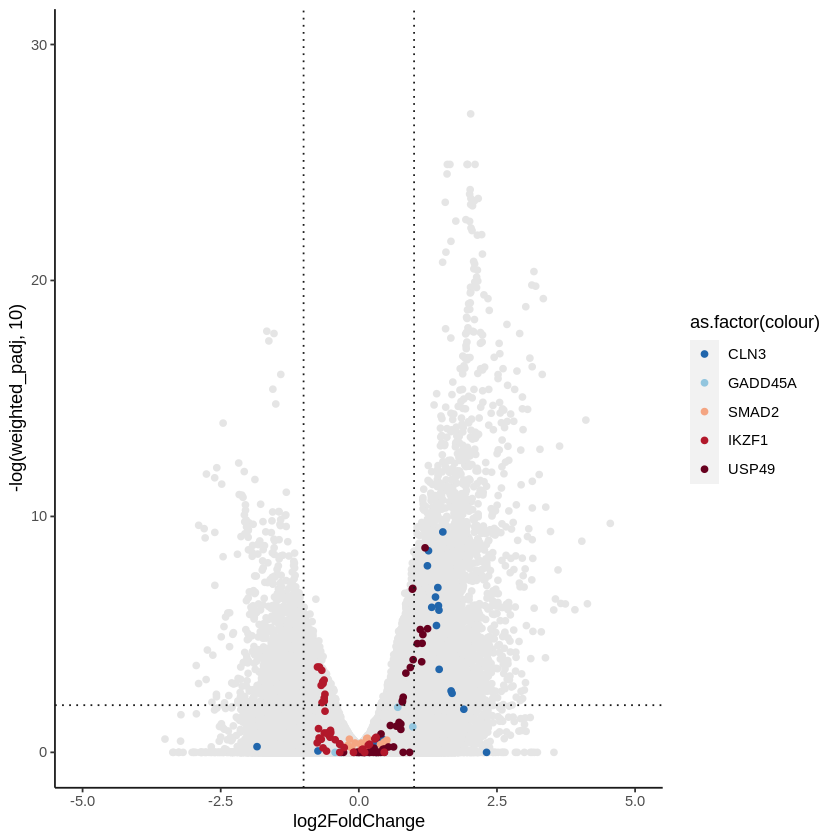

In [23]:
## factoring ILC3 genes for plotting

diffs_5kb_bmap[,colour:= ifelse(V5 == "CLN3", "CLN3", 
                                ifelse(V5 == "GADD45A", "GADD45A", 
                                       ifelse(V5 == "SMAD2", "SMAD2",
                                              ifelse(V5 == "IKZF1", "IKZF1", 
                                                     ifelse(V5 =="USP49", "USP49", "grey30")))))]
diffs_5kb_bmap[,colour := factor(colour, levels = c("CLN3", "GADD45A", "SMAD2", "IKZF1", "USP49", "grey30"))]

# plotting volcano plot chicdiff 5kb. Colouring ILC3 genes

ggplot(diffs_5kb_bmap[!(colour == "grey30")], aes(x=log2FoldChange, y=-log(weighted_padj, 10))) +
    geom_point(data = diffs_5kb_bmap[(colour == "grey30")], aes(x=log2FoldChange, y=-log(weighted_padj, 10)), colour = "grey90") +
    scale_color_manual(values=c("#2166ac", "#92c5de", "#f4a582", "#b2182b", "#67001f")) +
    geom_point(aes(colour = as.factor(colour)), alpha = 1) +
    ylim(c(0,30)) +
    xlim(c(-5,5)) +
    geom_hline(yintercept=2, linetype='dotted', col = 'grey10') +
    geom_vline(xintercept=-1, linetype='dotted', col = 'grey10') +
    geom_vline(xintercept=1, linetype='dotted', col = 'grey10') +
    theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(), 
          panel.background = element_blank(), axis.line = element_line(colour = "grey10"))
    

    

Warning message:
“Removed 2 rows containing missing values (geom_point).”


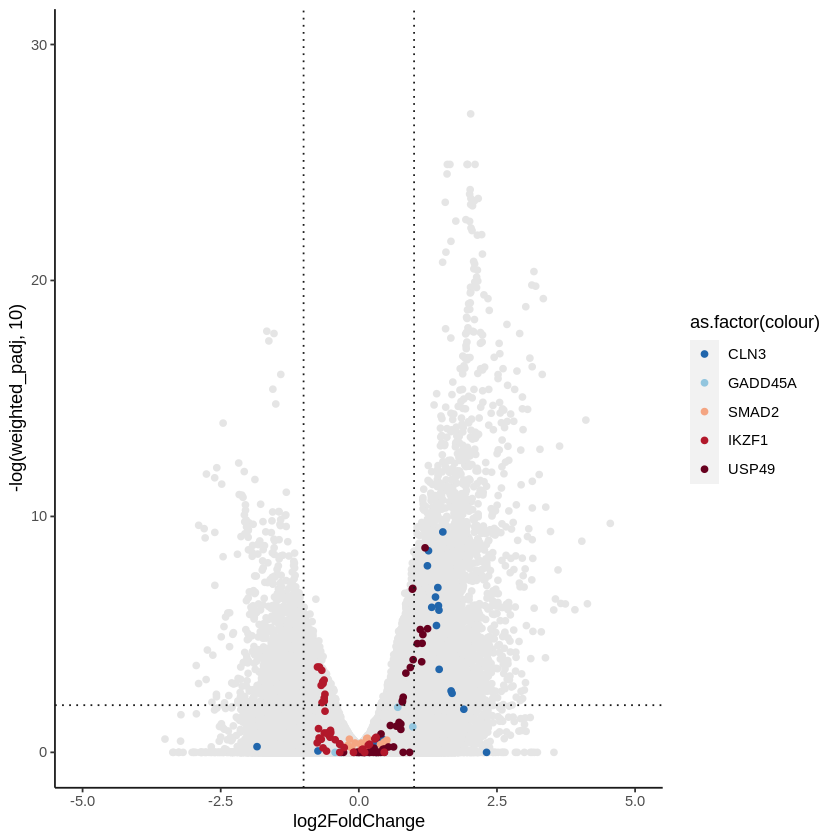

In [24]:
ggplot(diffs_5kb_bmap[!(colour == "grey30")], aes(x=log2FoldChange, y=-log(weighted_padj, 10))) +
    geom_point(data = diffs_5kb_bmap[(colour == "grey30")], aes(x=log2FoldChange, y=-log(weighted_padj, 10)), colour = "grey90") +
    scale_color_manual(values=c("#2166ac", "#92c5de", "#f4a582", "#b2182b", "#67001f")) +
    geom_point(aes(colour = as.factor(colour)), alpha = 1) +
    ylim(c(0,30)) +
    xlim(c(-5,5)) +
    geom_hline(yintercept=2, linetype='dotted', col = 'grey10') +
    geom_vline(xintercept=-1, linetype='dotted', col = 'grey10') +
    geom_vline(xintercept=1, linetype='dotted', col = 'grey10') +
    theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(), 
          panel.background = element_blank(), axis.line = element_line(colour = "grey10"))
    


In [25]:
############## Load COGS results
# Feb 2025: updated results with new ABC
multicogs_ilc3 <- fread("~/spivakov_analysis_live/HRJ_monocytes/hILCs/COGS_results/COGS_out/Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
multicogs_cd4 <- fread("~/spivakov_analysis_live/HRJ_monocytes/hILCs/COGS_results/COGS_out/Version3_revision2/revision_deLange_CD4s_hg38_SuSIE_fix_combinedInteractions_extended_ABC023_5kbOnly/Annotated_COGS_scores_data.table.txt")

# multicogs <- fread("~/spivakov_analysis_live/miniPCHiC/hILCs/rcogs/ILC_vs_CD4_deLange_multiCOGS.txt")

In [26]:
multicogs_merge <- merge(multicogs_ilc3[,c("ensg", "gene", "cogs")], multicogs_cd4[,c("ensg", "cogs")], by = "ensg")
setnames(multicogs_merge, c("cogs.x", "cogs.y"), c("ILC3_cogs", "CD4_cogs"))

In [27]:
multicogs_ilc3_only <- multicogs_merge[CD4_cogs<0.5 & ILC3_cogs>=0.5]$gene
multicogs_cd4_only <- multicogs_merge[CD4_cogs>=0.5 & ILC3_cogs<0.5]$gene

In [28]:
multicogs_ilc3_only
multicogs_cd4_only

[1] "BTN3A1"        "GALC"          "SBNO2"         "IL12RB2"      
 [5] "ATG16L1"       "NCF4"          "AHSA1"         "SPTLC2"       
 [9] "RIPK2"         "TYK2"          "TNFSF8"        "GCNT2"        
[13] "CCR6"          "BTN2A1"        "INO80D"        "IL1R1"        
[17] "IL1RL1"        "IL18R1"        "LGALS8"        "TNFSF4"       
[21] "IRF6"          "CD244"         "SLC12A5"       "PRRG2"        
[25] "TNNT3"         "DDC"           "PTPN22"        "RBM17"        
[29] "IL2RA"         "GPR65"         "RORC"          "MRPL9"        
[33] "EAF2"          "VIPAS39"       "PTPRK"         "BATF"         
[37] "SLAMF8"        "IFNGR2"        "TGFBR2"        "CTD-2369P2.10"
[41] "CPT1C"         "MUS81"         "CFL1"          "PTPN2"        
[45] "HCLS1"         "TDRKH"         "IFITM2"        "BTN3A2"       
[49] "CLN3"          "FDX2"

[1] "TRAF3IP3" "CUL1"     "PRDM1"    "PIGV"     "ICAM3"    "PTPRC"   
 [7] "CREM"     "PSMA6"    "DOCK8"    "TSPAN14"  "CCND3"    "LNPEP"   
[13] "GNPDA1"   "IRF1"     "MYC"      "FRS3"     "DIRC2"    "IL19"    
[19] "CGN"      "POGZ"     "CISD2"    "RPL37"    "CCDC58"   "FCMR"    
[25] "SLC9B2"   "ZHX3"     "RAD51B"   "SATB1"    "UBE2V1"

In [29]:
ilc3_chicdiff_multicogs <- unique(diffs_5kb_bmap[log2FoldChange > 0 & weighted_padj < 0.05 & V5 %in% multicogs_ilc3_only]$V5)
cd4_chicdiff_multicogs <- unique(diffs_5kb_bmap[log2FoldChange < 0 & weighted_padj < 0.05 & V5 %in% multicogs_cd4_only]$V5)

In [30]:
ilc3_chicdiff_multicogs
cd4_chicdiff_multicogs

[1] "TDRKH"   "RORC"    "TNFSF4"  "CFL1"    "VIPAS39" "AHSA1"   "GPR65"  
 [8] "CLN3"    "TYK2"    "IL1R1"   "INO80D"  "EAF2"    "BTN3A2"  "BTN3A1" 
[15] "CCR6"

[1] "PTPRC"   "IL19"    "FCMR"    "CREM"    "TSPAN14" "ZHX3"    "SATB1"  
[8] "GNPDA1"  "PRDM1"

In [31]:
# --------------------------
# 4. Overlap chicdiff and deseq2 results
# --------------------------

res_ordered_dt <- fread("~/miniPCHiC/hILCs/rna_seq/ILC3_vs_CD4/DESeq2_results_ILC3_vs_CD4.csv")

## select chicdiff x deseq2 genes

ilc3_chicdiff_deseq <- unique(diffs_5kb_bmap[log2FoldChange > 0 & weighted_padj<=0.05][V5 %in% res_ordered_dt[padj<=0.05 & log2FoldChange>0]$rn]$V5)
cd4_chicdiff_deseq <- unique(diffs_5kb_bmap[log2FoldChange < 0 & weighted_padj<=0.05][V5 %in% res_ordered_dt[padj<=0.05 & log2FoldChange<0]$rn]$V5)

length(ilc3_chicdiff_deseq)
length(cd4_chicdiff_deseq)

[1] 672

[1] 303

In [32]:
res_ordered_dt[padj<=0.05 & log2FoldChange>0][rn == "TNFSF4"]

rn,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TNFSF4,5378.932,8.023128,0.5448908,14.72429,4.502013e-49,1.223378e-46


In [33]:
## select chicdiff x deseq2 genes

ilc3_chicdiff_deseq_multicogs <- unique(diffs_5kb_bmap[log2FoldChange > 1 & weighted_padj<=0.05][V5 %in% res_ordered_dt[padj<=0.05 & log2FoldChange>0]$rn][V5 %in% ilc3_chicdiff_multicogs]$V5)
cd4_chicdiff_deseq_multicogs <- unique(diffs_5kb_bmap[log2FoldChange < 1 & weighted_padj<=0.05][V5 %in% res_ordered_dt[padj<=0.05 & log2FoldChange<0]$rn][V5 %in% cd4_chicdiff_multicogs]$V5)

length(ilc3_chicdiff_deseq_multicogs)
length(cd4_chicdiff_deseq_multicogs)

[1] 5

[1] 3

In [34]:
chicdiff_deseq_multicogs <- c(ilc3_chicdiff_deseq_multicogs, cd4_chicdiff_deseq_multicogs)
chicdiff_deseq_multicogs

[1] "TDRKH"   "TNFSF4"  "VIPAS39" "GPR65"   "CLN3"    "FCMR"    "SATB1"  
[8] "PRDM1"

In [35]:
# Generate named colors from RColorBrewer
colors <- brewer.pal(8, "Set1")
gene_colors <- setNames(colors[1:length(chicdiff_deseq_multicogs)], chicdiff_deseq_multicogs)
head(gene_colors)

TDRKH    TNFSF4   VIPAS39     GPR65      CLN3      FCMR 
"#E41A1C" "#377EB8" "#4DAF4A" "#984EA3" "#FF7F00" "#FFFF33"

In [36]:
# Ensure diffs_5kb_bmap is a data.table or data.frame with gene names in a "Gene" column
diffs_5kb_bmap[, colour := ifelse(V5 %in% chicdiff_deseq_multicogs, V5, "other")]

Warning message:
“Removed 2 rows containing missing values (geom_point).”


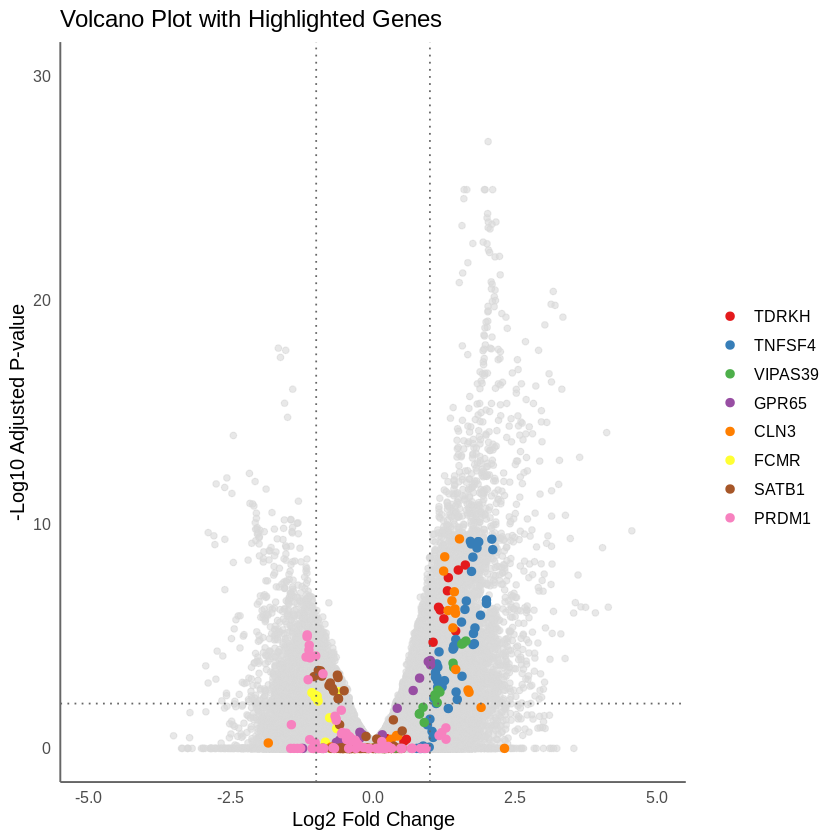

In [37]:
ggplot(diffs_5kb_bmap, aes(x = log2FoldChange, y = -log10(weighted_padj))) +
  # Base layer: grey for all other genes
  geom_point(data = diffs_5kb_bmap[colour == "other"], color = "grey85", alpha = 0.6) +

  # Highlighted genes with custom colors
  geom_point(data = diffs_5kb_bmap[colour != "other"],
             aes(color = colour),
             size = 2) +

  # Manual color scale
  scale_color_manual(values = gene_colors) +

  # Threshold lines
  geom_hline(yintercept = 2, linetype = "dotted", color = "grey40") +
  geom_vline(xintercept = c(-1, 1), linetype = "dotted", color = "grey40") +

  # Axis limits
  xlim(c(-5, 5)) +
  ylim(c(0, 30)) +

  # Theme tweaks
  theme_minimal(base_size = 12) +
  theme(
    panel.grid = element_blank(),
    axis.line = element_line(color = "grey40"),
    legend.title = element_blank()
  ) +
  labs(
    title = "Volcano Plot with Highlighted Genes",
    x = "Log2 Fold Change",
    y = "-Log10 Adjusted P-value"
  )


In [148]:

diffs_5kb_bmap[,colour_levels := ifelse(colour == "grey50", colour, V5)]

head(diffs_5kb_bmap)
# table(diffs_5kb_bmap[,c("colour_levels", "colour")]$colour_levels)
# table(diffs_5kb_bmap[,c("colour_levels", "colour")]$colour)

baitID,group,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maxOE,minOE,⋯,shuff,avgLogDist,avWeights,weight,weighted_pvalue,weighted_padj,V1,V2,V3,V5
<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<chr>
179,1,46.680262,0.59223839,0.3140923,1.88555536,0.05935490,0.1919646,175,165,⋯,0.6375649,10.26195,21.72550399,6.44612391,0.009207843,0.06285817,1,1013234,1013732,ISG15
179,7,13.311389,-0.44929346,0.5709557,-0.78691476,0.43133177,0.6491220,244,234,⋯,0.6388901,12.38331,0.46398274,0.13766724,3.133147397,1.00000000,1,1013234,1013732,ISG15
179,7,12.719230,-0.44662134,0.5960188,-0.74934109,0.45365165,0.6676433,248,238,⋯,0.4675856,12.43955,0.46398274,0.13766724,3.295276598,1.00000000,1,1013234,1013732,ISG15
179,8,9.861834,-0.06340615,0.6349468,-0.09986057,0.92045502,NA,259,249,⋯,0.7849545,12.57985,0.04047793,0.01201011,76.640004101,1.00000000,1,1013234,1013732,ISG15
179,9,6.690222,0.60230222,0.8214326,0.73323387,0.46341580,NA,277,267,⋯,0.2378068,12.77683,0.08020184,0.02379650,19.474113832,1.00000000,1,1013234,1013732,ISG15
234,1,53.379848,-0.64622283,0.3042581,-2.12393005,0.03367599,0.1316521,246,236,⋯,0.5011448,10.27270,21.72550399,6.44612391,0.005224224,0.04082428,1,1231014,1231913,SDF4/B3GALT6


Warning message:
“Removed 2 rows containing missing values (geom_point).”


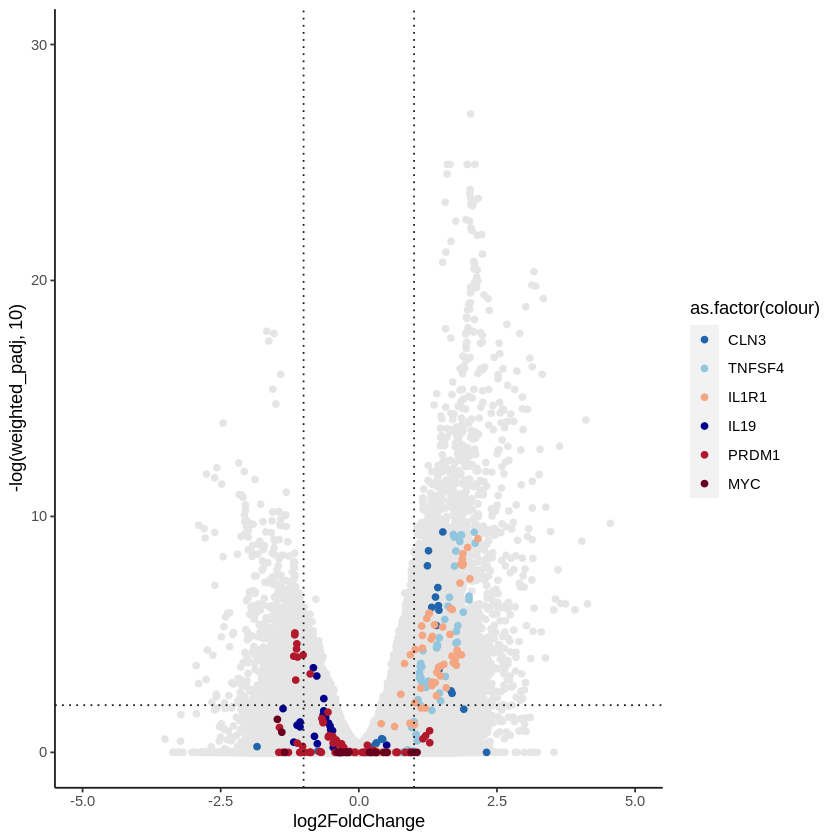

In [39]:
## factoring ILC3 genes for plotting

diffs_5kb_bmap[,colour:= ifelse(V5 == "CLN3", "CLN3", 
                                ifelse(V5 == "TNFSF4", "TNFSF4", 
                                       ifelse(V5 == "IL1R1", "IL1R1",
                            ifelse(V5 == "IL19", "IL19", 
                                ifelse(V5 == "PRDM1", "PRDM1", 
                                       ifelse(V5 == "MYC", "MYC",
                                              ifelse(V5 == "PTPRC", "PTPRC","grey30")))))))]
diffs_5kb_bmap[,colour := factor(colour, levels = c("CLN3", "TNFSF4", "IL1R1", "IL19", "PRDM1", "MYC","grey30"))]

# plotting volcano plot chicdiff 5kb. Colouring ILC3 genes

ggplot(diffs_5kb_bmap[!(colour == "grey30")], aes(x=log2FoldChange, y=-log(weighted_padj, 10))) +
    geom_point(data = diffs_5kb_bmap[(colour == "grey30")], aes(x=log2FoldChange, y=-log(weighted_padj, 10)), colour = "grey90") +
    scale_color_manual(values=c("#2166ac", "#92c5de", "#f4a582", "darkblue", "#b2182b", "#67001f")) +
    geom_point(aes(colour = as.factor(colour)), alpha = 1) +
    ylim(c(0,30)) +
    xlim(c(-5,5)) +
    geom_hline(yintercept=2, linetype='dotted', col = 'grey10') +
    geom_vline(xintercept=-1, linetype='dotted', col = 'grey10') +
    geom_vline(xintercept=1, linetype='dotted', col = 'grey10') +
    theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(), 
          panel.background = element_blank(), axis.line = element_line(colour = "grey10"))
    


In [87]:
ggsave("chicdiff_5kb_ILC_vs_CD4_multiCOGS_sel.pdf", device = "pdf", height =  5, width = 5)

Warning message:
“Removed 119 rows containing missing values (geom_point).”
Warning message:
“Removed 3 rows containing missing values (geom_point).”


In [40]:
# gene sets

ilc3_cd4_shared_chicdiff <- intersect(ilc3_diff_genes, cd4_diff_genes)
ilc3_only_chicdiff <- setdiff(ilc3_diff_genes, ilc3_cd4_shared_chicdiff)
cd4_only_chicdiff <- setdiff(cd4_diff_genes, ilc3_cd4_shared_chicdiff)
all_same_wired <- unique(c(unlist(strsplit(diffs_fres_bmap[weighted_padj > 0.05]$V5, ",")),unlist(strsplit(diffs_5kb_bmap[weighted_padj > 0.05]$V5, ","))))


In [49]:
## convert from symbol to entrezid

ilc3_diff_wired_entrez_ids <- bitr(ilc3_only_chicdiff, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
ilc3_cd4_shared_diff_wired_entrez_ids <- bitr(ilc3_cd4_shared_chicdiff, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
cd4_diff_wired_entrez_ids <- bitr(cd4_only_chicdiff, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
nondiff_wired_entrez_ids <- bitr(all_same_wired, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(ilc3_only_chicdiff, fromType = "SYMBOL", toType = "ENTREZID", :
“12.87% of input gene IDs are fail to map...”
'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(ilc3_cd4_shared_chicdiff, fromType = "SYMBOL", toType = "ENTREZID", :
“3.61% of input gene IDs are fail to map...”
'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(cd4_only_chicdiff, fromType = "SYMBOL", toType = "ENTREZID", :
“6.67% of input gene IDs are fail to map...”


In [95]:
# ILC3-specific
ego_bp_ilc3_diff <- enrichGO(gene         = ilc3_diff_wired_entrez_ids$ENTREZID,
                   OrgDb        = org.Hs.eg.db,
                   keyType      = "ENTREZID",
                   ont          = "BP",
                   pAdjustMethod = "BH",
                   pvalueCutoff  = 0.05,
                   qvalueCutoff  = 0.05,
                   readable      = TRUE)
fwrite(as.data.table(ego_bp_ilc3_diff), "ego_bp_ilc3_chicdiff_genes.txt")

# CD4-specific
ego_bp_cd4_diff <- enrichGO(gene         = cd4_diff_wired_entrez_ids$ENTREZID,
                   OrgDb        = org.Hs.eg.db,
                   keyType      = "ENTREZID",
                   ont          = "BP",
                   pAdjustMethod = "BH",
                   pvalueCutoff  = 0.05,
                   qvalueCutoff  = 0.05,
                   readable      = TRUE)

fwrite(as.data.table(ego_bp_cd4_diff), "ego_bp_cd4_chicdiff_genes.txt")

# CD4-ILC3-diff_shared
ego_bp_ilc3_cd4_diff <- enrichGO(gene         = ilc3_cd4_shared_diff_wired_entrez_ids$ENTREZID,
                   OrgDb        = org.Hs.eg.db,
                   keyType      = "ENTREZID",
                   ont          = "BP",
                   pAdjustMethod = "BH",
                   pvalueCutoff  = 0.05,
                   qvalueCutoff  = 0.05,
                   readable      = TRUE)


fwrite(as.data.table(ego_bp_ilc3_cd4_diff), "ego_bp_ilc3_cd4_chicdiff_genes.txt")

# non-diff
ego_bp_nondiff <- enrichGO(gene         = nondiff_wired_entrez_ids$ENTREZID,
                   OrgDb        = org.Hs.eg.db,
                   keyType      = "ENTREZID",
                   ont          = "BP",
                   pAdjustMethod = "BH",
                   pvalueCutoff  = 0.05,
                   qvalueCutoff  = 0.05,
                   readable      = TRUE)

fwrite(as.data.table(ego_bp_nondiff), "ego_bp_nochicdiff_genes.txt")

In [142]:

shared_terms <- Reduce(intersect, list(as.data.table(ego_bp_ilc3_cd4_diff)[qvalue < 0.05]$Description, 
                                       as.data.table(ego_bp_cd4_diff)[qvalue < 0.05]$Description, 
                                       as.data.table(ego_bp_ilc3_diff)[qvalue < 0.05]$Description))
head(shared_terms)

as.data.table(ego_bp_ilc3_cd4_diff)[Description == "T cell activation"]$geneID
as.data.table(ego_bp_cd4_diff)[Description == "T cell activation"]$geneID
as.data.table(ego_bp_ilc3_diff)[Description == "T cell activation"]$geneID


[1] "T cell receptor signaling pathway" "T cell activation"

In [146]:
text_size = 12
width = 8
height = 4
gene_number = 20

## CD4-spec diff genes

cd4_diff_wired_plot <- dotplot(ego_bp_cd4_diff, showCategory = gene_number) +
scale_x_continuous(name = "Gene Ratio", limits = c(0, 0.06)) +
  theme(axis.text.x = element_text(size = text_size),
        axis.text.y = element_text(size = text_size))

ggsave("goterms_cd4_dotplot_adjusted.pdf", plot = cd4_diff_wired_plot, width = width, height = height, useDingbats = FALSE)

# CD4-ILC3-diff_shared
ilc3_cd4_shared_diff_wired_plot <- dotplot(ego_bp_ilc3_cd4_diff, showCategory = gene_number) +
scale_x_continuous(name = "Gene Ratio", limits = c(0, 0.1)) +
  theme(axis.text.x = element_text(size = text_size),
        axis.text.y = element_text(size = text_size))

ggsave("goterms_ilc3_cd4_shared_diff_dotplot_adjusted.pdf", plot = ilc3_cd4_shared_diff_wired_plot, width = width, height = height,  useDingbats = FALSE)

# ILC3-specific
ilc3_diff_wired_plot <- dotplot(ego_bp_ilc3_diff, showCategory = gene_number)   +
scale_x_continuous(name = "Gene Ratio", limits = c(0, 0.06)) +
  theme(axis.text.x = element_text(size = text_size),
        axis.text.y = element_text(size = text_size))

ggsave("goterms_ilc3_dotplot_adjusted.pdf", plot = ilc3_diff_wired_plot, width = width, height = height, useDingbats = FALSE)

# non-diff
nondiff_plot <- dotplot(ego_bp_nondiff, showCategory = gene_number) +  
scale_x_continuous(name = "Gene Ratio", limits = c(0, 0.04)) +
  theme(axis.text.x = element_text(size = text_size),
        axis.text.y = element_text(size = text_size))

ggsave("nondiff_wired3_dotplot_adjusted.pdf", plot = nondiff_plot, width = width, height = height,  useDingbats = FALSE)

In [9]:
## plotting chicdiff baits for GO genes

## 5kb sol baits - ILC3-specific

# ego_bp_ilc3_chicdiff <- fread("~/miniPCHiC/hILCs/Chicdiff/ego_bp_ilc3_chicdiff_genes.txt")
# ego_bp_ilc3_chicdiff_genes <- unlist(strsplit(ego_bp_ilc3_chicdiff[Description %in% c("regulation of innate immune response",
#                                                                                       "regulation of immune effector process")]$geneID, "/"))

# ego_bp_ilc3_chicdiff_genes_baits <- fread(bmap_5kb)[V5 %in% ego_bp_ilc3_chicdiff_genes & 
#                                                     V4 %in% diffs_5kb[weighted_padj < 0.05]$baitID]$V4
# length(ego_bp_ilc3_chicdiff_genes_baits)

# countputRds <- "~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_DII_5kb/ILC_CD4_DII_5kb_countput.Rds"

# dir.create("~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_DII_5kb/ilc3_spec_GO_term_plots")
# setwd("~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_DII_5kb/ilc3_spec_GO_term_plots")

# for(i in 1:length(ego_bp_ilc3_chicdiff_genes_baits)){
#     pdf(paste0(ego_bp_ilc3_chicdiff_genes_baits[i], ".pdf"))
#     print(plotDiffBaits(diffs_5kb, countputRds, bmap_5kb, ego_bp_ilc3_chicdiff_genes_baits[i], xlim=c(-5e5,5e5), plotBmean = TRUE))
#     dev.off()
# }

## 5kb sol baits - CD4-speciic

# ego_bp_cd4_chicdiff <- fread("~/miniPCHiC/hILCs/Chicdiff/ego_bp_cd4_chicdiff_genes.txt")
# ego_bp_cd4_chicdiff_genes <- unlist(strsplit(ego_bp_cd4_chicdiff[Description %in% c("regulation of T cell activation",
#                                                                                      "negative regulation of MAPK cascade")]$geneID, "/"))

# ego_bp_cd4_chicdiff_genes_baits <- fread(bmap_5kb)[V5 %in% ego_bp_cd4_chicdiff_genes & 
#                                                     V4 %in% diffs_5kb[weighted_padj < 0.05]$baitID]$V4
# length(ego_bp_cd4_chicdiff_genes_baits)

# countputRds <- "~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_DII_5kb/ILC_CD4_DII_5kb_countput.Rds"

# dir.create("~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_DII_5kb/cd4_spec_GO_term_plots")
# setwd("~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_DII_5kb/cd4_spec_GO_term_plots")

# for(i in 1:length(ego_bp_cd4_chicdiff_genes_baits)){
#     pdf(paste0(ego_bp_cd4_chicdiff_genes_baits[i], ".pdf"))
#     print(plotDiffBaits(diffs_5kb, countputRds, bmap_5kb, ego_bp_cd4_chicdiff_genes_baits[i], xlim=c(-5e5,5e5), plotBmean = TRUE))
#     dev.off()
# }

## 5kb sol baits - ILC3 and CD4-speciic

ego_bp_ilc3_cd4_chicdiff <- fread("~/miniPCHiC/hILCs/Chicdiff/ego_bp_ilc3_cd4_chicdiff_genes.txt")
ego_bp_ilc3_cd4_chicdiff_genes <- unlist(strsplit(ego_bp_ilc3_cd4_chicdiff[Description %in% c("regulation of T cell activation",
                                                                                     "immune response-activating cell surface receptor signaling pathway")]$geneID, "/"))

ego_bp_ilc3_cd4_chicdiff_genes_baits <- fread(bmap_5kb)[V5 %in% ego_bp_ilc3_cd4_chicdiff_genes & 
                                                    V4 %in% diffs_5kb[weighted_padj < 0.05]$baitID]$V4
length(ego_bp_ilc3_cd4_chicdiff_genes_baits)

countputRds <- "~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_DII_5kb/ILC_CD4_DII_5kb_countput.Rds"

dir.create("~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_DII_5kb/ilc3_cd4_spec_GO_term_plots")
setwd("~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_DII_5kb/ilc3_cd4_spec_GO_term_plots")

for(i in 1:length(ego_bp_ilc3_cd4_chicdiff_genes_baits)){
    pdf(paste0(ego_bp_ilc3_cd4_chicdiff_genes_baits[i], ".pdf"))
    print(plotDiffBaits(diffs_5kb, countputRds, bmap_5kb, ego_bp_ilc3_cd4_chicdiff_genes_baits[i], xlim=c(-5e5,5e5), plotBmean = TRUE))
    dev.off()
}

# ## fragment resolution

# go_bait_list_for_chicdiff_fres <- fread(bmap_fres)[V5 %in% 
#                                       c("NFKB1", "TLR3", "IFNG", "IL23R", "NCR3", "SOCS5", "CD3E", "CD86", 
#                                         "CTLA4", "DUSP14", "DUSP16", "PTPN6", "CD226", "CCR7", "CD300A", 
#                                         "PIK3R1", "ZAP70", "RORC", "ITK", "CD28") & V4 %in% 
#                                       diffs_fres[weighted_padj < 0.05]$baitID]$V4

# length(go_bait_list_for_chicdiff_fres)
# go_bait_list_for_chicdiff_fres

# ## plotting chicdiff baits for GO genes

# countputRds_fres <- "~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_fragres/ILC_CD4_fragres_countput.Rds"

# dir.create("~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_fragres/GO_term_plots")
# setwd("~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_fragres/GO_term_plots")

# for(i in 1:length(go_bait_list_for_chicdiff_fres)){
#     pdf(paste0(go_bait_list_for_chicdiff_fres[i], ".pdf"))
#     print(plotDiffBaits(diffs_fres, countputRds_fres, bmap_fres, go_bait_list_for_chicdiff_fres[i], xlim=c(-1e5,1e5), plotBmean = TRUE))
#     dev.off()
# }


# ego_bp_cd4_chicdiff <- fread("~/miniPCHiC/hILCs/Chicdiff/ego_bp_cd4_chicdiff_genes.txt")
# ego_bp_cd4_chicdiff_genes <- unlist(strsplit(ego_bp_cd4_chicdiff[Description %in% c("regulation of T cell activation",
#                                                                                      "negative regulation of MAPK cascade")]$geneID, "/"))

# ego_bp_cd4_chicdiff_genes_baits_fres <- fread(bmap_fres)[V5 %in% ego_bp_cd4_chicdiff_genes & 
#                                                     V4 %in% diffs_fres[weighted_padj < 0.05]$baitID]$V4
# length(ego_bp_cd4_chicdiff_genes_baits_fres)

# countputRds_fres <- "~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_fragres/ILC_CD4_fragres_countput.Rds"

# dir.create("~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_fragres/cd4_spec_GO_term_plots")
# setwd("~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_fragres/cd4_spec_GO_term_plots")

# for(i in 1:length(ego_bp_cd4_chicdiff_genes_baits_fres)){
#     pdf(paste0(ego_bp_cd4_chicdiff_genes_baits_fres[i], ".pdf"))
#     print(plotDiffBaits(diffs_fres, countputRds_fres, bmap_fres, ego_bp_cd4_chicdiff_genes_baits_fres[i], xlim=c(-1e5,1e5), plotBmean = TRUE))
#     dev.off()
# }

[1] 39

Warning message in dir.create("~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_DII_5kb/ilc3_cd4_spec_GO_term_plots"):
“'/rds/general/user/malyshev/home/miniPCHiC/hILCs/Chicdiff/ILC_CD4_DII_5kb/ilc3_cd4_spec_GO_term_plots' already exists”


In [13]:
#CLN3 exploration
# ilc_5kb <- readRDS("~/miniPCHiC/hILCs/hILCs_run2/Chicago/with_binning_5kb_solbaits/hILCs_all_merged_bin_Step2/data/hILCs_all_merged_bin_Step2.Rds")
# cd4_5kb <- readRDS("~/miniPCHiC/PCHiC_DpnII_merged/Chicago/with_binning/M1_bin5K_merged_Step2/data/M1_bin5K_merged_Step2.Rds")

rmap_5kb <- fread("~/spivakov_analysis_live/Design/Human_hg38_bin5K_sol_baits/human_DpnII_5K_sol_baits.rmap")
 

ilc_5kb_sel <- merge(ilc_5kb@x[score>5], rmap_5kb, by.x = "otherEndID", by.y = "V4")
cd4_5kb_sel <- merge(cd4_5kb@x[score>5], rmap_5kb, by.x = "otherEndID", by.y = "V4")

# bmap_5kb[V5 =="CLN3"]
# 16	28491286	28491852	186283	CLN3
# 16	28491910	28492066	186286	CLN3 - no interactions in ILC3s and CD4+ T cells
# 16	28492067	28492254	186288	CLN3 - no interactions in CD4+ T cells
# 16	28492255	28492527	186289	CLN3
# 16	28494992	28496471	186293	CLN3 - no interactions in ILC3s and CD4+ T cells

ilc_5kb_sel[baitID == "186289"]
cd4_5kb_sel[baitID == "186289"]

# CLN3_5kbsb_baits <-fread(bmap_5kb)[V5 == "CLN3" & V4 %in% diffs_5kb[weighted_padj < 0.05]$baitID]$V4
# CLN3_5kbsb_baits

# setwd("~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_DII_5kb/GO_term_plots")
# for(i in 1:length(CLN3_5kbsb_baits)){
#     pdf(paste0(CLN3_5kbsb_baits[i], ".pdf"))
#     print(plotDiffBaits(diffs_5kb, countputRds, bmap_5kb, CLN3_5kbsb_baits[i], xlim=c(-1e6,1e6), plotBmean = TRUE))
#     dev.off()
# }


# CLN3_fres_baits <-fread(bmap_fres)[V5 == "CLN3" & V4 %in% diffs_fres[weighted_padj < 0.05]$baitID]$V4
# CLN3_fres_baits

# setwd("~/miniPCHiC/hILCs/Chicdiff/ILC_CD4_fragres/GO_term_plots")
# for(i in 1:length(CLN3_fres_baits)){
#     pdf(paste0(CLN3_fres_baits[i], ".pdf"))
#     print(plotDiffBaits(diffs_fres, countputRds_fres, bmap_fres, CLN3_fres_baits[i], xlim=c(-1e5,1e5), plotBmean = TRUE))
#     dev.off()
# }

otherEndID,baitID,distbin,s_j,otherEndLen,distSign,isBait2bait,N.1,N.2,N.3,⋯,tblb,Tmean,Bmean,log.p,log.w,log.q,score,V1,V2,V3
<int>,<int>,<fct>,<dbl>,<int>,<int>,<lgl>,<int>,<int>,<int>,⋯,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>
186237,186289,"(1.8e+05,2e+05]",1.142756,5825,-196708,FALSE,6,0,8,⋯,"[1831,6459]",0.014942064,0.7666304,-7.013894,7.532162,-14.54606,6.941069,16,28292770,28298595
186277,186289,"(0,2e+04]",1.142756,5007,-19443,FALSE,25,11,23,⋯,"[1831,6459]",0.014942064,5.5405568,-6.398192,7.604797,-14.00299,6.398002,16,28470444,28475451
186278,186289,"(0,2e+04]",1.142756,5176,-14351,FALSE,31,23,28,⋯,"[1831,6459]",0.014942064,7.5578950,-6.683053,7.604901,-14.28795,6.682966,16,28475452,28480628
186282,186289,"(0,2e+04]",1.142756,3181,-2696,FALSE,144,91,137,⋯,"[1831,6459]",0.014942064,46.1496152,-5.416112,7.604986,-13.02110,5.416111,16,28488104,28491285
186295,186289,"(0,2e+04]",1.142756,4267,11649,FALSE,33,15,37,⋯,"[1831,6459]",0.014942064,9.4179280,-5.872515,7.604937,-13.47745,5.872465,16,28501906,28506173
186297,186289,"(0,2e+04]",1.142756,5560,17514,FALSE,32,21,56,⋯,"[1831,6459]",0.014942064,6.1571707,-14.270581,7.604842,-21.87542,14.270437,16,28507125,28512685
186298,186289,"(2e+04,4e+04]",1.142756,5231,22911,FALSE,34,27,31,⋯,"[1831,6459]",0.014942064,4.7073749,-13.048032,7.604697,-20.65273,13.047742,16,28512686,28517917
186301,186289,"(2e+04,4e+04]",1.142756,5141,39122,FALSE,17,10,20,⋯,"[1831,6459]",0.014942064,2.8339688,-9.660909,7.603830,-17.26474,9.659751,16,28528942,28534083
186305,186289,"(4e+04,6e+04]",1.142756,5083,54448,FALSE,22,22,29,⋯,"[1831,6459]",0.014942064,2.1096258,-20.285201,7.602267,-27.88747,20.282481,16,28544297,28549380


otherEndID,baitID,distbin,s_j,otherEndLen,distSign,isBait2bait,N.1,N.2,N,⋯,tblb,Tmean,Bmean,log.p,log.w,log.q,score,V1,V2,V3
<int>,<int>,<fct>,<dbl>,<int>,<int>,<lgl>,<int>,<int>,<dbl>,⋯,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>
186237,186289,"(1.8e+05,2e+05]",0.6879163,5825,-196708,FALSE,4,9,7,⋯,"[1304,1442)",0.007330279,0.8217453,-7.539760,7.532162,-15.07192,7.466935,16,28292770,28298595
186304,186289,"(4e+04,6e+04]",0.6879163,5068,49371,FALSE,9,20,15,⋯,"[1304,1442)",0.007330279,2.8592194,-7.011583,7.602875,-14.61446,7.009471,16,28539228,28544296
186305,186289,"(4e+04,6e+04]",0.6879163,5083,54448,FALSE,15,17,16,⋯,"[1304,1442)",0.007330279,2.6016485,-8.316769,7.602267,-15.91904,8.314049,16,28544297,28549380
186306,186289,"(4e+04,6e+04]",0.6879163,4134,59057,FALSE,21,23,22,⋯,"[1304,1442)",0.007330279,2.4070402,-13.170433,7.601632,-20.77206,13.167078,16,28549381,28553515
186308,186289,"(6e+04,8e+04]",0.6879163,5609,64418,FALSE,15,17,16,⋯,"[1304,1442)",0.007330279,2.2164421,-9.602526,7.600788,-17.20331,9.598327,16,28554004,28559613


In [16]:
cd4_5kb@x[baitID==186289 & otherEndID == 186278]

baitID,otherEndID,distbin,s_j,otherEndLen,distSign,isBait2bait,N.1,N.2,N,⋯,NNb,NNboe,tlb,tblb,Tmean,Bmean,log.p,log.w,log.q,score
<int>,<int>,<fct>,<dbl>,<int>,<int>,<lgl>,<int>,<int>,<dbl>,⋯,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
186289,186278,"(0,2e+04]",0.6879163,5176,-14351,FALSE,16,23,20,⋯,29,28,"(98,284]","[1304,1442)",0.007330279,9.983195,-2.417547,7.604901,-10.02245,2.417461
